In [24]:
import os
import io
import time
import math
import random
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import joblib
import tempfile

import os, warnings
# Tell loky how many cores to use so it won't call `wmic`
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 1)

# (Optional) silence this specific warning completely
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores",
    category=UserWarning
)


# ---------------------------
# Configuration
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Windows paths (use raw strings)
NONCRACK_DIR = r"C:\Users\Rehab Jadallah\Desktop\SD_Crack_Classification\Concrete_Crack\0_Non_Crack"
CRACK_DIR = r"C:\Users\Rehab Jadallah\Desktop\SD_Crack_Classification\Concrete_Crack\1_Crack"

IMG_SIZE = (128, 128)
USE_GRAYSCALE = True     # set False to use RGB (much higher dimensional)
AUG_PER_IMAGE = 2        # how many augmented samples per training image (0 to disable)
TEST_SIZE = 0.20

In [25]:
# ---------------------------
# Utilities
# ---------------------------
def is_image_file(p: Path) -> bool:
    return p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def load_and_preprocess(path: Path, img_size: Tuple[int, int], grayscale: bool = True) -> np.ndarray:
    """Load an image file and return a flattened numpy array after resizing (and grayscale if chosen)."""
    with Image.open(path) as img:
        # Convert
        if grayscale:
            img = img.convert("L")
        else:
            img = img.convert("RGB")
        # Resize with high-quality resampling
        img = img.resize(img_size, Image.BICUBIC)
        arr = np.asarray(img, dtype=np.float32)
        # Normalize to [0,1]
        arr = arr / 255.0
        # Flatten
        return arr.flatten()

def augment_pil(img: Image.Image) -> Image.Image:
    """Apply a random but mild augmentation to a PIL Image and return an augmented PIL Image."""
    # Random horizontal flip
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    # Small rotation (-10° to 10°)
    angle = random.uniform(-10, 10)
    img = img.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=0 if img.mode == "L" else (0, 0, 0))
    # Slight translation (±5% of size)
    tx = int(random.uniform(-0.05, 0.05) * img.width)
    ty = int(random.uniform(-0.05, 0.05) * img.height)
    img = img.transform(img.size, Image.AFFINE, (1, 0, tx, 0, 1, ty), resample=Image.BICUBIC, fillcolor=0 if img.mode == "L" else (0, 0, 0))
    # Brightness jitter (0.8–1.2)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    return img

def pil_from_array_feature(x: np.ndarray, img_size: Tuple[int, int], grayscale: bool) -> Image.Image:
    """Reconstruct a PIL Image from feature vector for augmentation previews (used only on training set)."""
    if grayscale:
        arr = (x.reshape(img_size) * 255.0).clip(0, 255).astype(np.uint8)
        return Image.fromarray(arr, mode="L")
    else:
        c = 3
        arr = (x.reshape(img_size[1], img_size[0], c) * 255.0).clip(0, 255).astype(np.uint8)
        return Image.fromarray(arr, mode="RGB")

def model_size_kb(model) -> float:
    import io, joblib
    buf = io.BytesIO()
    joblib.dump(model, buf, compress=3)
    return len(buf.getvalue()) / 1024.0

def avg_inference_time_ms(model, X: np.ndarray) -> float:
    """Average per-image inference time in milliseconds."""
    # Measure single-sample prediction time to be comparable across models
    start = time.perf_counter()
    for i in range(X.shape[0]):
        _ = model.predict(X[i:i+1])
    elapsed = time.perf_counter() - start
    return (elapsed / X.shape[0]) * 1000.0

In [26]:
# ---------------------------
# Load dataset
# ---------------------------
def load_dataset(noncrack_dir: str, crack_dir: str, img_size: Tuple[int, int], grayscale: bool) -> Tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    for label, folder in [(0, noncrack_dir), (1, crack_dir)]:
        for p in Path(folder).rglob("*"):
            if p.is_file() and is_image_file(p):
                try:
                    feat = load_and_preprocess(p, img_size, grayscale=grayscale)
                    X.append(feat)
                    y.append(label)
                except Exception as e:
                    print(f"[WARN] Skipped {p} due to error: {e}")
    X = np.vstack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

print("Loading images...")
X, y = load_dataset(NONCRACK_DIR, CRACK_DIR, IMG_SIZE, USE_GRAYSCALE)
print(f"Loaded {X.shape[0]} images. Feature dim = {X.shape[1]}")

Loading images...
Loaded 140 images. Feature dim = 16384


In [4]:
# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

In [5]:
# ---------------------------
# Data augmentation on training set
# ---------------------------
if AUG_PER_IMAGE > 0:
    print(f"Augmenting training data (x{AUG_PER_IMAGE})...")
    aug_features = []
    aug_labels = []
    # Reconstruct minimal PIL image from features for augmentation
    for xi, yi in zip(X_train, y_train):
        img = pil_from_array_feature(xi, IMG_SIZE, USE_GRAYSCALE)
        for _ in range(AUG_PER_IMAGE):
            aug_img = augment_pil(img.copy())
            aug_img = aug_img.resize(IMG_SIZE, Image.BICUBIC)
            arr = np.asarray(aug_img, dtype=np.float32) / 255.0
            aug_features.append(arr.flatten())
            aug_labels.append(yi)
    if aug_features:
        X_aug = np.vstack(aug_features).astype(np.float32)
        y_aug = np.array(aug_labels, dtype=np.int64)
        X_train = np.vstack([X_train, X_aug])
        y_train = np.concatenate([y_train, y_aug])
        print(f"Training set after augmentation: {X_train.shape[0]} samples")

Augmenting training data (x2)...
Training set after augmentation: 336 samples


In [8]:
# ---------------------------
# Define models
# ---------------------------
models: Dict[str, Pipeline] = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", LogisticRegression(
            solver="saga", penalty="l2", max_iter=5000, random_state=SEED, n_jobs=-1))
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", SVC(kernel="rbf", probability=False, random_state=SEED))
    ]),
    "DecisionTree": Pipeline([
        ("scaler", "passthrough"),
        ("clf", DecisionTreeClassifier(max_depth=None, random_state=SEED))
    ]),
    "RandomForest": Pipeline([
        ("scaler", "passthrough"),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED))
    ]),
    "KNN_k5": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", KNeighborsClassifier(n_neighbors=5, weights="distance"))
    ]),
    "MLP_1x256": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(256,), activation="relu", solver="adam",
            learning_rate_init=1e-3, max_iter=200, random_state=SEED, early_stopping=True))
    ]),
}

In [27]:
# ---------------------------
# Train, evaluate, report
# ---------------------------
def evaluate_model(name: str, pipe: Pipeline, X_train: np.ndarray, y_train: np.ndarray,
                   X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    print(f"\n=== Training {name} ===")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
    rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)

    # Inference latency
    inf_ms = avg_inference_time_ms(pipe, X_test)

    # Model size
    size_kb = model_size_kb(pipe)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "inference_ms_per_image": inf_ms,
        "model_size_kb": size_kb
    }

results = {}
for name, pipe in models.items():
    metrics = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    results[name] = metrics


=== Training LogisticRegression ===

=== Training SVM_RBF ===

=== Training DecisionTree ===

=== Training RandomForest ===

=== Training KNN_k5 ===

=== Training MLP_1x256 ===


In [28]:
# ---------------------------
# Print results in a table
# ---------------------------
def nice(num, digits=4):
    if isinstance(num, (int, np.integer)):
        return str(num)
    return f"{num:.{digits}f}"

headers = ["Model", "Accuracy", "Precision", "Recall", "F1", "ms/img", "Size (KB)"]
col_widths = [max(len(h), 14) for h in headers]

def print_row(cols):
    print(" | ".join(str(c).ljust(w) for c, w in zip(cols, col_widths)))

print("\n\n===== Evaluation Results =====")
print_row(headers)
print("-" * (sum(col_widths) + 3 * (len(headers) - 1)))
for name, m in results.items():
    row = [
        name,
        nice(m["accuracy"]),
        nice(m["precision"]),
        nice(m["recall"]),
        nice(m["f1"]),
        nice(m["inference_ms_per_image"]),
        nice(m["model_size_kb"])
    ]
    print_row(row)



===== Evaluation Results =====
Model          | Accuracy       | Precision      | Recall         | F1             | ms/img         | Size (KB)     
--------------------------------------------------------------------------------------------------------------------
LogisticRegression | 0.5714         | 1.0000         | 0.1429         | 0.2500         | 0.2222         | 383.6641      
SVM_RBF        | 0.7500         | 1.0000         | 0.5000         | 0.6667         | 32.0647        | 19511.5928    
DecisionTree   | 0.7500         | 0.8889         | 0.5714         | 0.6957         | 0.0726         | 2.2920        
RandomForest   | 0.7500         | 0.8889         | 0.5714         | 0.6957         | 39.4401        | 349.4727      
KNN_k5         | 0.5357         | 1.0000         | 0.0714         | 0.1333         | 284.0511       | 19826.9873    
MLP_1x256      | 0.6786         | 0.8571         | 0.4286         | 0.5714         | 2.7826         | 46064.7031    


In [29]:
# Optional: brief class balance check
unique, counts = np.unique(y, return_counts=True)
print("\nClass counts (full dataset):", dict(zip(unique.tolist(), counts.tolist())))
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Done.")


Class counts (full dataset): {0: 70, 1: 70}
Train size: 336  Test size: 28
Done.


In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# --- Random Forest config (match your earlier params if desired) ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=SEED,
    n_jobs=1  # use 1 to avoid loky/wmic warnings on Windows
)

# --- 5-fold Stratified CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Scoring: binary classification assumes class "1" is positive
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = cross_validate(
    rf, X, y,
    scoring=scoring,
    cv=cv,
    return_train_score=False,
    n_jobs=1  # parallelize if you've set LOKY_MAX_CPU_COUNT
)

# --- Print per-fold metrics ---
print("===== 5-Fold CV: Random Forest =====")
for i in range(cv.get_n_splits()):
    print(f"Fold {i+1}: "
          f"Acc={cv_results['test_accuracy'][i]:.4f}  "
          f"Prec={cv_results['test_precision'][i]:.4f}  "
          f"Rec={cv_results['test_recall'][i]:.4f}  "
          f"F1={cv_results['test_f1'][i]:.4f}")

# --- Print mean ± std ---
def mean_std(arr):
    return np.mean(arr), np.std(arr, ddof=1)

acc_m, acc_s = mean_std(cv_results['test_accuracy'])
pre_m, pre_s = mean_std(cv_results['test_precision'])
rec_m, rec_s = mean_std(cv_results['test_recall'])
f1_m,  f1_s  = mean_std(cv_results['test_f1'])

print("\nOverall (mean ± std):")
print(f"Accuracy : {acc_m:.4f} ± {acc_s:.4f}")
print(f"Precision: {pre_m:.4f} ± {pre_s:.4f}")
print(f"Recall   : {rec_m:.4f} ± {rec_s:.4f}")
print(f"F1-score : {f1_m:.4f} ± {f1_s:.4f}")

===== 5-Fold CV: Random Forest =====
Fold 1: Acc=0.6429  Prec=0.6667  Rec=0.5714  F1=0.6154
Fold 2: Acc=0.7857  Prec=1.0000  Rec=0.5714  F1=0.7273
Fold 3: Acc=0.5714  Prec=0.5833  Rec=0.5000  F1=0.5385
Fold 4: Acc=0.7143  Prec=0.8000  Rec=0.5714  F1=0.6667
Fold 5: Acc=0.5357  Prec=0.5263  Rec=0.7143  F1=0.6061

Overall (mean ± std):
Accuracy : 0.6500 ± 0.1023
Precision: 0.7153 ± 0.1896
Recall   : 0.5857 ± 0.0782
F1-score : 0.6308 ± 0.0707


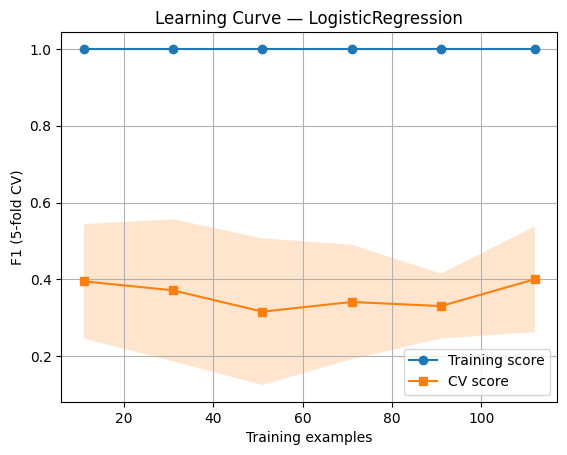

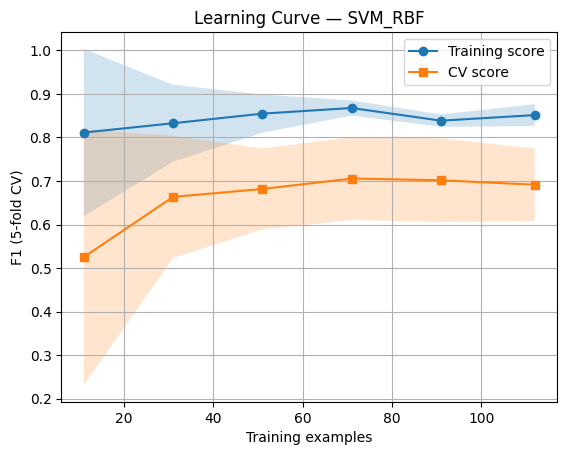

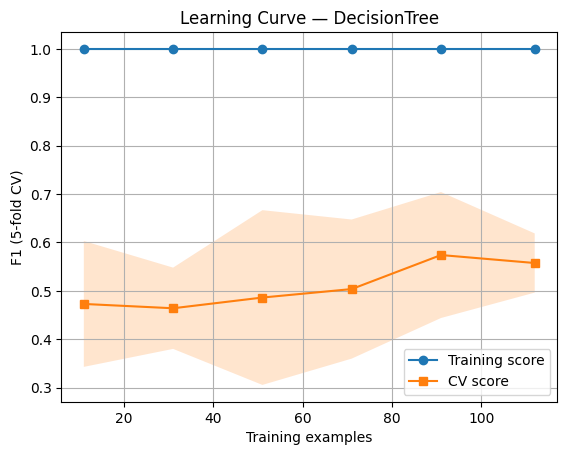

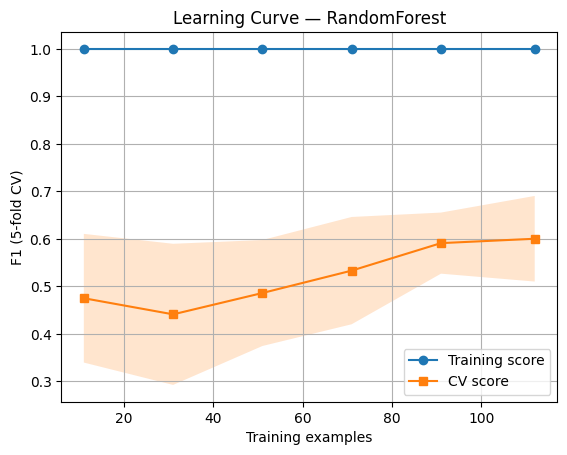

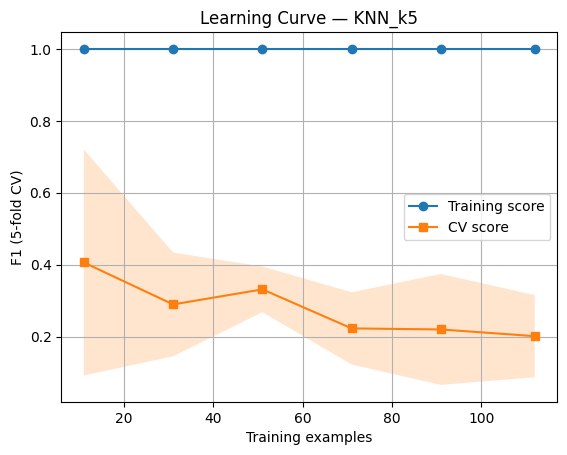

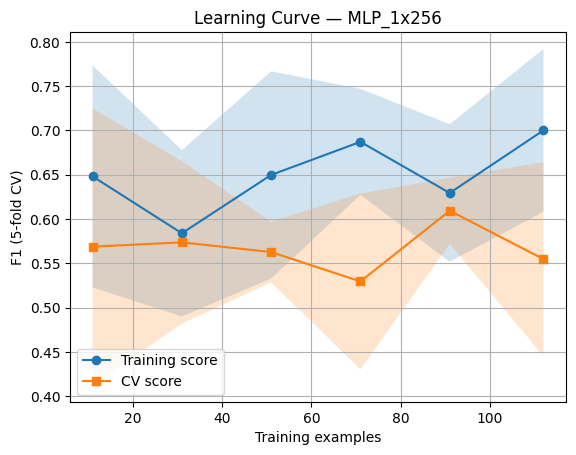

Training MLP once to capture loss curve...


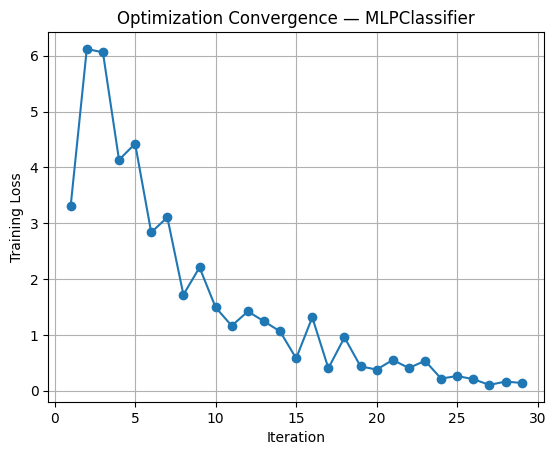


===== Hyperparameters (classifier step) =====

--- LogisticRegression ---
{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 5000,
 'multi_class': 'deprecated',
 'n_jobs': -1,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'saga',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

--- SVM_RBF ---
{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

--- DecisionTree ---
{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter

In [31]:
# --- Convergence (learning) curves for all models + training loss curve for MLP ---

from sklearn.model_selection import StratifiedKFold, learning_curve
import matplotlib.pyplot as plt

# CV settings (matches your earlier usage)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def plot_learning_curve_for_pipeline(name, pipe, X, y, cv, n_jobs=1):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y,
        cv=cv,
        n_jobs=n_jobs,
        scoring="f1",              # use F1 as a balanced signal; change to "accuracy" if you prefer
        train_sizes=np.linspace(0.1, 1.0, 6),
        shuffle=True,
        random_state=SEED
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1, ddof=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1, ddof=1)

    plt.figure()
    plt.title(f"Learning Curve — {name}")
    plt.xlabel("Training examples")
    plt.ylabel("F1 (5-fold CV)")
    # shaded std (no explicit colors per your tooling best practices)
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.2)
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, val_mean,   marker="s", label="CV score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plot learning curves for every model in your dictionary
for name, pipe in models.items():
    # If you set the WMIC workaround earlier, you can raise n_jobs to speed this up
    plot_learning_curve_for_pipeline(name, pipe, X, y, cv=cv, n_jobs=1)

# --- True optimization (loss) convergence curve for the MLP only ---
if "MLP_1x256" in models:
    print("Training MLP once to capture loss curve...")
    mlp_pipe = models["MLP_1x256"]
    # Fit on the training split (not CV) to obtain the iterative loss trajectory
    mlp_pipe.fit(X_train, y_train)
    mlp = mlp_pipe.named_steps["clf"]
    if hasattr(mlp, "loss_curve_") and mlp.loss_curve_:
        plt.figure()
        plt.title("Optimization Convergence — MLPClassifier")
        plt.xlabel("Iteration")
        plt.ylabel("Training Loss")
        plt.plot(range(1, len(mlp.loss_curve_)+1), mlp.loss_curve_, marker="o")
        plt.grid(True)
        plt.show()
    else:
        print("[INFO] No loss_curve_ available (try increasing max_iter or disable early_stopping).")

# --- Print hyperparameters of each model (classifier step of the pipeline) ---

from pprint import pprint

def print_model_hyperparams(models_dict):
    print("\n===== Hyperparameters (classifier step) =====")
    for name, pipe in models_dict.items():
        clf = pipe.named_steps["clf"]
        print(f"\n--- {name} ---")
        # Keep it tidy: only the classifier's own params (not the entire pipeline)
        params = clf.get_params(deep=False)
        pprint(params)

print_model_hyperparams(models)

# TensorFlow Lite Model for Mobile Deployment

Now we'll train a CNN using TensorFlow/Keras and convert it to TensorFlow Lite format for mobile deployment.


In [14]:
# ---------------------------
# Install TensorFlow if needed
# ---------------------------
import subprocess
import sys

try:
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    print("Installing TensorFlow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")


Installing TensorFlow...
TensorFlow version: 2.20.0


In [15]:
# ---------------------------
# Prepare data for CNN (reshape from flattened to 2D images)
# ---------------------------
from tensorflow import keras

# Reshape data: CNN expects (batch, height, width, channels)
# We used 128x128 grayscale, so shape should be (n_samples, 128, 128, 1)
X_train_cnn = X_train.reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
X_test_cnn = X_test.reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)

print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")


Training data shape: (336, 128, 128, 1)
Test data shape: (28, 128, 128, 1)
Training labels shape: (336,)
Test labels shape: (28,)


In [16]:
# ---------------------------
# Build CNN Model
# ---------------------------

# Set TensorFlow random seed for reproducibility
tf.random.set_seed(SEED)

model = keras.Sequential([
    # Input layer
    keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
    
    # First convolutional block
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    
    # Second convolutional block
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    
    # Third convolutional block
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    
    # Dense layers
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    
    # Output layer (sigmoid for binary classification)
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\n===== CNN Model Architecture =====")
model.summary()



===== CNN Model Architecture =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,710,241 (33.23 MB)

 Trainable params: 8,709,281 (33.22 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
# ---------------------------
# Train CNN Model
# ---------------------------

# Early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n===== Training CNN =====")
history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✓ Training completed!")



===== Training CNN =====
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5923 - loss: 0.8419 - precision: 0.5803 - recall: 0.6667 - val_accuracy: 0.5000 - val_loss: 0.7649 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6786 - loss: 0.7215 - precision: 0.6667 - recall: 0.7143 - val_accuracy: 0.5000 - val_loss: 0.8239 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7411 - loss: 0.6023 - precision: 0.7580 - recall: 0.7083 - val_accuracy: 0.5000 - val_loss: 0.7821 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 960ms/step - accuracy: 0.8006 - loss: 0.4178 - precision: 0.8098 - recall: 0.7857 - val_accuracy: 0.5000 - val_loss: 0.7884 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
11/

In [18]:
# ---------------------------
# Evaluate CNN Model
# ---------------------------

# Get predictions
y_pred_probs = model.predict(X_test_cnn)
y_pred_cnn = (y_pred_probs > 0.5).astype(int).flatten()

# Calculate metrics
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
cnn_precision = precision_score(y_test, y_pred_cnn, average='binary', zero_division=0)
cnn_recall = recall_score(y_test, y_pred_cnn, average='binary', zero_division=0)
cnn_f1 = f1_score(y_test, y_pred_cnn, average='binary', zero_division=0)

# Model size
cnn_size_kb = model_size_kb(model)

# Inference time
start_time = time.perf_counter()
for i in range(X_test_cnn.shape[0]):
    _ = model.predict(X_test_cnn[i:i+1], verbose=0)
elapsed = time.perf_counter() - start_time
cnn_inf_ms = (elapsed / X_test_cnn.shape[0]) * 1000.0

print("\n===== CNN Evaluation Results =====")
print(f"Accuracy:  {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall:    {cnn_recall:.4f}")
print(f"F1-score:  {cnn_f1:.4f}")
print(f"Inference: {cnn_inf_ms:.2f} ms/image")
print(f"Model Size: {cnn_size_kb:.2f} KB")

# Compare with best sklearn model (Random Forest)
print(f"\n--- Comparison with Random Forest ---")
print(f"CNN Accuracy: {cnn_accuracy:.4f} vs RF Accuracy: {results['RandomForest']['accuracy']:.4f}")
print(f"CNN F1-score: {cnn_f1:.4f} vs RF F1-score: {results['RandomForest']['f1']:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step

===== CNN Evaluation Results =====
Accuracy:  0.5000
Precision: 0.5000
Recall:    1.0000
F1-score:  0.6667
Inference: 106.87 ms/image
Model Size: 95490.83 KB

--- Comparison with Random Forest ---
CNN Accuracy: 0.5000 vs RF Accuracy: 0.7500
CNN F1-score: 0.6667 vs RF F1-score: 0.6957


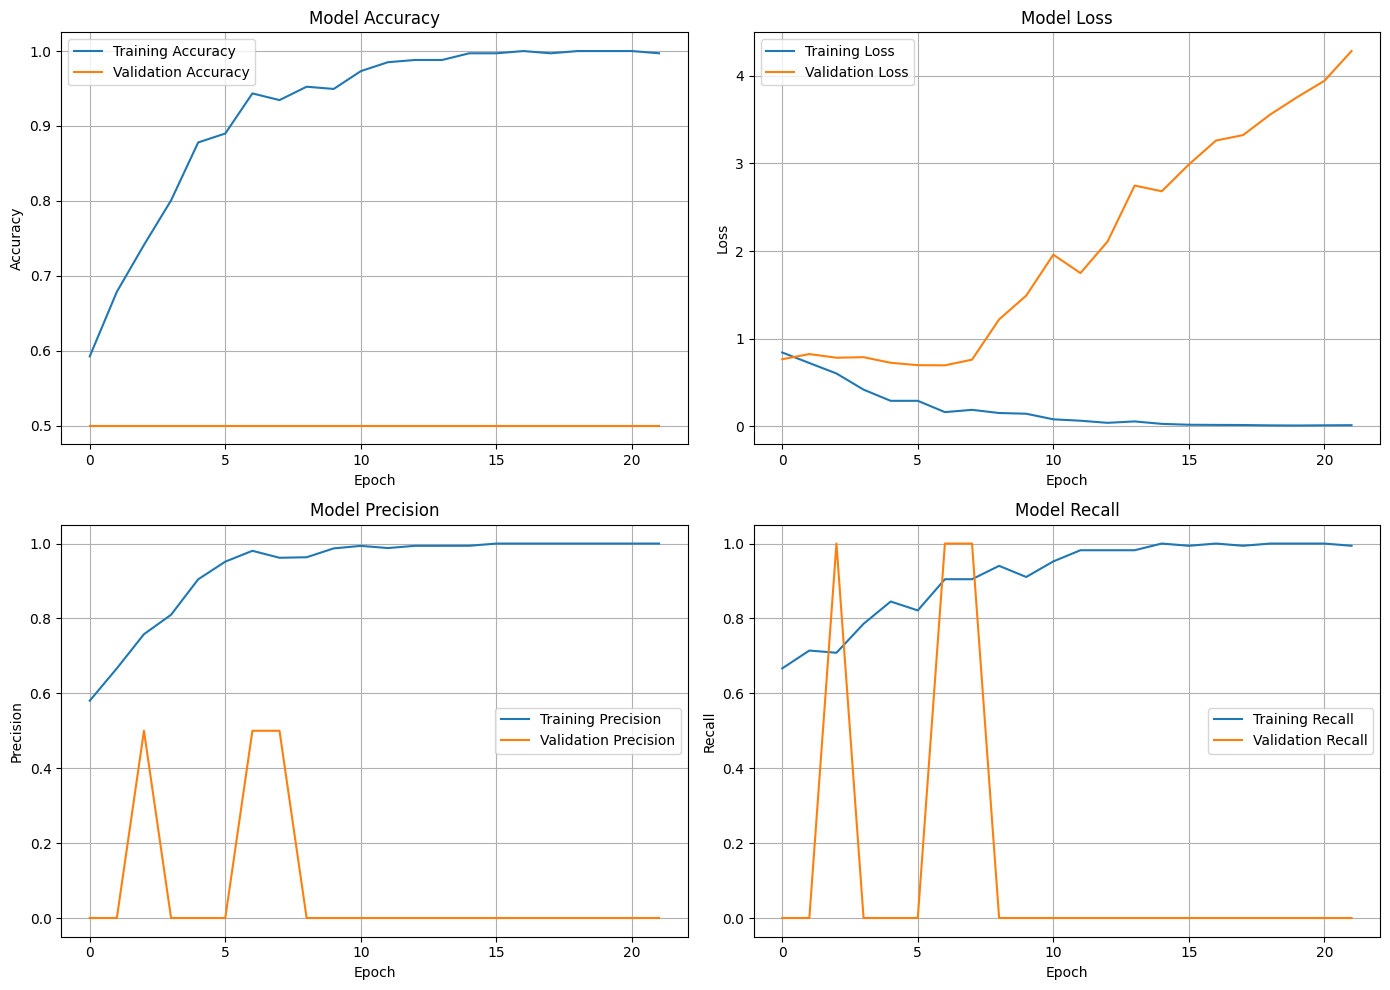

In [19]:
# ---------------------------
# Plot Training History
# ---------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Training Loss')
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall')
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


In [20]:
# ---------------------------
# Convert to TensorFlow Lite
# ---------------------------

print("Converting model to TensorFlow Lite format...")

# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization: quantize model for smaller size and faster inference
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Optional: Representative dataset for better quantization (using a subset of training data)
def representative_dataset():
    for i in range(min(100, X_train_cnn.shape[0])):
        yield [X_train_cnn[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset

# Enable supported ops for better compatibility
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,  # TFLite builtin ops
    tf.lite.OpsSet.SELECT_TF_OPS      # Some TensorFlow ops
]

# Convert the model
tflite_model = converter.convert()

# Save the TFLite model
tflite_path = 'crack_detector.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size_kb = len(tflite_model) / 1024.0
print(f"\n✓ TensorFlow Lite model saved to: {tflite_path}")
print(f"✓ TFLite model size: {tflite_size_kb:.2f} KB")
print(f"✓ Size reduction: {cnn_size_kb:.2f} KB → {tflite_size_kb:.2f} KB ({(1 - tflite_size_kb/cnn_size_kb)*100:.1f}% smaller)")


Converting model to TensorFlow Lite format...
INFO:tensorflow:Assets written to: C:\Users\REHABJ~1\AppData\Local\Temp\tmpteht6h62\assets


INFO:tensorflow:Assets written to: C:\Users\REHABJ~1\AppData\Local\Temp\tmpteht6h62\assets


Saved artifact at 'C:\Users\REHABJ~1\AppData\Local\Temp\tmpteht6h62'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2311206513232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206514960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206513424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206514576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206514000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206513616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206514192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206515920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206515536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2311206516496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  23

c:\Users\Rehab Jadallah\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



✓ TensorFlow Lite model saved to: crack_detector.tflite
✓ TFLite model size: 8536.14 KB
✓ Size reduction: 95490.83 KB → 8536.14 KB (91.1% smaller)


In [22]:
# ---------------------------
# Test TFLite Model (Verify it works correctly)
# ---------------------------

print("\n===== Testing TFLite Model =====")

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape: {input_details[0]['shape']}")
print(f"Input type: {input_details[0]['dtype']}")
print(f"Output shape: {output_details[0]['shape']}")
print(f"Output type: {output_details[0]['dtype']}")

# Test on all test images
y_pred_tflite = []
start_time = time.perf_counter()

for i in range(X_test_cnn.shape[0]):
    # Prepare input
    input_data = X_test_cnn[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    
    # Run inference
    interpreter.invoke()
    
    # Get output
    output_data = interpreter.get_tensor(output_details[0]['index'])
    y_pred_tflite.append(1 if output_data[0][0] > 0.5 else 0)

elapsed = time.perf_counter() - start_time
tflite_inf_ms = (elapsed / X_test_cnn.shape[0]) * 1000.0

# Convert to array
y_pred_tflite = np.array(y_pred_tflite)

# Calculate metrics for TFLite
tflite_accuracy = accuracy_score(y_test, y_pred_tflite)
tflite_precision = precision_score(y_test, y_pred_tflite, average='binary', zero_division=0)
tflite_recall = recall_score(y_test, y_pred_tflite, average='binary', zero_division=0)
tflite_f1 = f1_score(y_test, y_pred_tflite, average='binary', zero_division=0)

print(f"\n--- TFLite Model Performance ---")
print(f"Accuracy:  {tflite_accuracy:.4f}")
print(f"Precision: {tflite_precision:.4f}")
print(f"Recall:    {tflite_recall:.4f}")
print(f"F1-score:  {tflite_f1:.4f}")
print(f"Inference: {tflite_inf_ms:.2f} ms/image")

# Verify predictions match original model
matching = np.sum(y_pred_cnn == y_pred_tflite)
print(f"\nPrediction consistency: {matching}/{len(y_pred_cnn)} ({matching/len(y_pred_cnn)*100:.1f}%)")

if matching == len(y_pred_cnn):
    print("✓ TFLite model predictions match the original Keras model perfectly!")
else:
    print("⚠ Some predictions differ (likely due to quantization)")



===== Testing TFLite Model =====
Input shape: [  1 128 128   1]
Input type: <class 'numpy.float32'>
Output shape: [1 1]
Output type: <class 'numpy.float32'>

--- TFLite Model Performance ---
Accuracy:  0.5000
Precision: 0.5000
Recall:    1.0000
F1-score:  0.6667
Inference: 6.12 ms/image

Prediction consistency: 28/28 (100.0%)
✓ TFLite model predictions match the original Keras model perfectly!


c:\Users\Rehab Jadallah\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [23]:
# ---------------------------
# Final Summary: All Models Comparison
# ---------------------------

print("\n\n" + "="*80)
print("FINAL MODEL COMPARISON (Including CNN)")
print("="*80)

# Add CNN results to the comparison
results['CNN'] = {
    "accuracy": cnn_accuracy,
    "precision": cnn_precision,
    "recall": cnn_recall,
    "f1": cnn_f1,
    "inference_ms_per_image": cnn_inf_ms,
    "model_size_kb": cnn_size_kb
}

results['CNN_TFLite'] = {
    "accuracy": tflite_accuracy,
    "precision": tflite_precision,
    "recall": tflite_recall,
    "f1": tflite_f1,
    "inference_ms_per_image": tflite_inf_ms,
    "model_size_kb": tflite_size_kb
}

# Print updated table
headers = ["Model", "Accuracy", "Precision", "Recall", "F1", "ms/img", "Size (KB)"]
col_widths = [max(len(h), 18) for h in headers]

def print_row(cols):
    print(" | ".join(str(c).ljust(w) for c, w in zip(cols, col_widths)))

print_row(headers)
print("-" * (sum(col_widths) + 3 * (len(headers) - 1)))

for name, m in results.items():
    row = [
        name,
        nice(m["accuracy"]),
        nice(m["precision"]),
        nice(m["recall"]),
        nice(m["f1"]),
        nice(m["inference_ms_per_image"]),
        nice(m["model_size_kb"])
    ]
    print_row(row)

# Find best model
best_f1_model = max(results.items(), key=lambda x: x[1]['f1'])
print(f"\n🏆 Best F1-score: {best_f1_model[0]} ({best_f1_model[1]['f1']:.4f})")

print("\n" + "="*80)
print("✓ TFLite model 'crack_detector.tflite' is ready for mobile deployment!")
print("="*80)




FINAL MODEL COMPARISON (Including CNN)
Model              | Accuracy           | Precision          | Recall             | F1                 | ms/img             | Size (KB)         
------------------------------------------------------------------------------------------------------------------------------------------------
LogisticRegression | 0.5714             | 1.0000             | 0.1429             | 0.2500             | 0.1988             | 383.6641          
SVM_RBF            | 0.7500             | 1.0000             | 0.5000             | 0.6667             | 28.3505            | 19511.5928        
DecisionTree       | 0.7500             | 0.8889             | 0.5714             | 0.6957             | 0.0783             | 2.2920            
RandomForest       | 0.7500             | 0.8889             | 0.5714             | 0.6957             | 40.0920            | 349.4727          
KNN_k5             | 0.5357             | 1.0000             | 0.0714             | 0.133